In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Lendingclub/lc_loan.csv')

/tmp/ipykernel_3999/3033285178.py:1: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Lendingclub/lc_loan.csv')


In [ ]:
# The number of lines is the number of rows
num_lines = len(df)
print(f"The lc_loan.csv file has {num_lines} lines.")

The lc_loan.csv file has 887379 lines.


In [ ]:
# CELL 1: Load & keep useful columns


cols_to_keep = [
    'id', 'loan_amnt', 'term', 'int_rate','issue_d','revol_util',
    'emp_length', 'annual_inc', 'loan_status','verification_status',
    'dti', 'delinq_2yrs', 'desc', 'purpose', 'title',
    'pub_rec', 'total_acc','inq_last_6mths'
]

df = df[df.columns.intersection(cols_to_keep)].copy()

# save cleaned subset if needed
df.to_csv('/content/drive/MyDrive/Lendingclub/loantodo.csv', index=False)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   887379 non-null  int64  
 1   loan_amnt            887379 non-null  float64
 2   term                 887379 non-null  object 
 3   int_rate             887379 non-null  float64
 4   emp_length           842554 non-null  object 
 5   annual_inc           887375 non-null  float64
 6   verification_status  887379 non-null  object 
 7   issue_d              887379 non-null  object 
 8   loan_status          887379 non-null  object 
 9   desc                 126026 non-null  object 
 10  purpose              887379 non-null  object 
 11  title                887226 non-null  object 
 12  dti                  887379 non-null  float64
 13  delinq_2yrs          887350 non-null  float64
 14  inq_last_6mths       887350 non-null  float64
 15  pub_rec          

In [ ]:
num_lines = len(df)
print(f"The loantodo file has {num_lines} lines.")

The loantodo file has 887379 lines.


In [ ]:
# CELL 2: Clean term & loan_status
# =======================

# term: "36 months" -> 36 (integer)
df['term'] = df['term'].astype(str).str.replace(' months', '', regex=False).astype(int)

# The df.dropna() line was too aggressive and is removed here.
# Missing values will be handled more specifically later in the notebook.

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Target encoding
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

print(df.shape)

#status_replace = {
    #'Fully Paid': 1,
    #'Charged Off': 0,
    #'Current': 1,
    #'Default': 0,
    #'Late (31-120 days)': 0,
    #'In Grace Period': 1,
    #'Late (16-30 days)': 0,
    #'Does not meet the credit policy. Status:Fully Paid': 1,
    #'Does not meet the credit policy. Status:Charged Off': 0
#}
#df['loan_status'] = df['loan_status'].str.strip().replace(status_replace)

print(df['loan_status'].value_counts(dropna=False).head())
print(df[['loan_status']].head())

(252971, 18)
loan_status
0    207723
1     45248
Name: count, dtype: int64
   loan_status
0            0
1            1
2            0
3            0
5            0


In [ ]:
# CELL 3: Clean text & build "comment"
# =======================

import re

clean_desc = df['desc'].copy()

pattern = r"Borrower added on \d{1,2}/\d{1,2}/\d{2}\s*>"
clean_desc = clean_desc.str.replace(pattern, "", regex=True)

clean_desc = clean_desc.str.replace("<br><br>", " ", regex=False)
clean_desc = clean_desc.str.replace("<br>", " ", regex=False)

clean_desc = clean_desc.str.split().str.join(" ")

df['clean_desc'] = clean_desc

# treat empty strings as missing
df['clean_desc'].replace("", np.nan, inplace=True)
df['title'].replace("", np.nan, inplace=True)
df['purpose'].replace("", np.nan, inplace=True)

# priority: clean_desc -> title -> purpose
df['comment'] = df['clean_desc'].fillna(df['title']).fillna(df['purpose'])


/tmp/ipykernel_3999/2596555395.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['clean_desc'].replace("", np.nan, inplace=True)
/tmp/ipykernel_3999/2596555395.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
print("Shape before dropping NaNs:", df.shape)
df.dropna(inplace=True)
print("Shape after dropping NaNs:", df.shape)

# Display info to show non-null counts
df.info()

Shape before dropping NaNs: (252971, 20)
Shape after dropping NaNs: (84946, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 84946 entries, 0 to 884008
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   84946 non-null  int64  
 1   loan_amnt            84946 non-null  float64
 2   term                 84946 non-null  int64  
 3   int_rate             84946 non-null  float64
 4   emp_length           84946 non-null  object 
 5   annual_inc           84946 non-null  float64
 6   verification_status  84946 non-null  object 
 7   issue_d              84946 non-null  object 
 8   loan_status          84946 non-null  int64  
 9   desc                 84946 non-null  object 
 10  purpose              84946 non-null  object 
 11  title                84946 non-null  object 
 12  dti                  84946 non-null  float64
 13  delinq_2yrs          84946 non-null  float64
 14  inq_last_6

In [ ]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

In [ ]:
!pip install textblob

In [38]:
from textblob import TextBlob

def get_textblob_sentiment(text):
    if text is None:
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

df['textblob_sentiment_score'] = df['comment'].apply(get_textblob_sentiment)

display(df[['comment', 'textblob_sentiment_score']].head())

,comment,textblob_sentiment_score
0,I need to upgrade my business technologies.,0.000000
1,I plan to use this money to finance the motorc...,0.266667
3,"to pay for property tax (borrow from friend, n...",-0.162500
7,Downpayment for a car.,0.000000
8,I own a small home-based judgment collection b...,0.090000


In [ ]:
def get_textblob_sentiment_label(score: float) -> int:
    if score > 0.1:
        return 1
    elif score < -0.1:
        return -1
    else:
        return 0

df['textblob_sentiment_label'] = df['textblob_sentiment_score'].apply(get_textblob_sentiment_label)


display(df[['comment', 'textblob_sentiment_score', 'textblob_sentiment_label']].head(10))

,comment,textblob_sentiment_score,textblob_sentiment_label
0,I need to upgrade my business technologies.,0.000000,0
1,I plan to use this money to finance the motorc...,0.266667,1
3,"to pay for property tax (borrow from friend, n...",-0.162500,-1
7,Downpayment for a car.,0.000000,0
8,I own a small home-based judgment collection b...,0.090000,0
9,I'm trying to build up my credit history. I li...,0.190115,1
10,I had recived a loan from Citi Financial about...,0.000000,0
12,Plan to pay off 2 charge accounts. I will clos...,-0.175000,-1
13,I intend to pay this debt off within half the ...,0.208333,1
17,Payoff other lending club acct and pull out mo...,-0.062500,0


In [40]:
#create the emp_length
df['emp_length_new'] = (
    df['emp_length'].astype(str)
    .str.replace(' years', '', regex=False)
    .str.replace(' year', '', regex=False)
    .str.replace('+', '', regex=False)
    .str.replace('< 1', '0', regex=False)
    .astype(float)
)

display(df[['emp_length', 'emp_length_new']].head())

,emp_length,emp_length_new
0,10+ years,10.0
1,< 1 year,0.0
3,10+ years,10.0
7,9 years,9.0
8,4 years,4.0


In [39]:
# Apply custom mapping for verification_status
verification_map = {'Verified': 1, 'Not Verified': -1, 'Source Verified': 0}
df['verification_status_encoded'] = df['verification_status'].map(verification_map)

display(df[['verification_status', 'verification_status_encoded']].head())

,verification_status,verification_status_encoded
0,Verified,1
1,Source Verified,0
3,Source Verified,0
7,Source Verified,0
8,Source Verified,0


In [ ]:
TARGET_COL = "loan_status"

NUMERIC_COLS = [
    "loan_amnt",
    "term",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "pub_rec",
    "revol_util",
    "total_acc",
    "issue_year",
    "issue_month",
    "textblob_sentiment_score",
    "emp_length_new","verification_status_encoded"
]

CATEGORICAL_COLS = [
    "textblob_sentiment_label"
]

# Now filter the DataFrame to include only the desired columns
df = df[NUMERIC_COLS + CATEGORICAL_COLS + [TARGET_COL]].copy()
df.head()

,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,pub_rec,revol_util,total_acc,issue_year,issue_month,textblob_sentiment_score,emp_length_new,verification_status_encoded,textblob_sentiment_label,loan_status
0,5000.0,36,10.65,24000.0,27.65,0.0,1.0,0.0,83.7,9.0,2011,12,0.000000,10.0,1,0,0
1,2500.0,60,15.27,30000.0,1.00,0.0,5.0,0.0,9.4,4.0,2011,12,0.266667,0.0,0,1,1
3,10000.0,36,13.49,49200.0,20.00,0.0,1.0,0.0,21.0,37.0,2011,12,-0.162500,10.0,0,-1,0
7,3000.0,36,18.64,48000.0,5.35,0.0,2.0,0.0,87.5,4.0,2011,12,0.000000,9.0,0,0,0
8,5600.0,60,21.28,40000.0,5.55,0.0,2.0,0.0,32.6,13.0,2011,12,0.090000,4.0,0,0,1


/tmp/ipykernel_3999/1586505991.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loans_per_year.index, y=loans_per_year.values, palette='viridis')


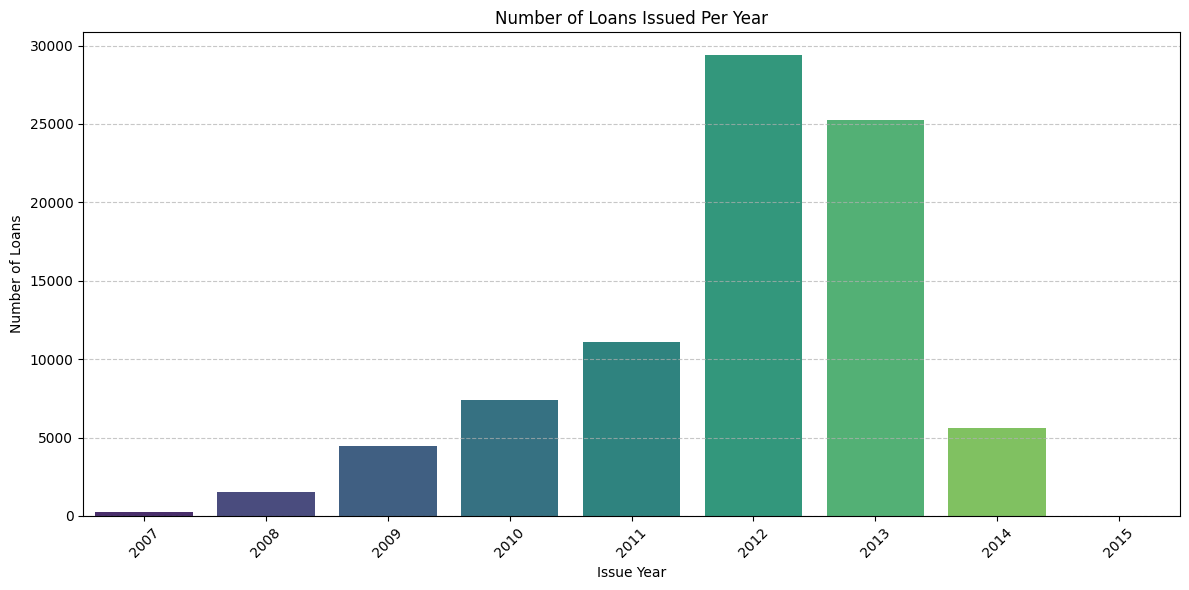

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the count of loans per year and sort by year
loans_per_year = df['issue_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=loans_per_year.index, y=loans_per_year.values, palette='viridis')
plt.title('Number of Loans Issued Per Year')
plt.xlabel('Issue Year')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
loans_per_year = df['issue_year'].value_counts().sort_index()
print(loans_per_year)

issue_year
2007      246
2008     1554
2009     4470
2010     7367
2011    11076
2012    29377
2013    25263
2014     5590
2015        3
Name: count, dtype: int64


In [ ]:
# ===== XÓA dummy cũ trước =====
df = df.loc[:, ~df.columns.str.startswith('issue_year_')]

# ===== Tạo biến giả (dummy variables) cho issue_year =====
issue_year_dummies = pd.get_dummies(
    df['issue_year'],
    prefix='issue_year',
    dtype=int
)

# ===== Ghép vào DataFrame gốc =====
df = pd.concat([df, issue_year_dummies], axis=1)

# ===== Lưu tên cột =====
issue_year_cols = issue_year_dummies.columns.tolist()

# ===== Xem thử =====
print(df.head())

KeyError: 'issue_year'

In [ ]:
issue_year_dummies = pd.get_dummies(df['issue_year'], prefix='issue_year', dtype=int)
df = pd.concat([df.drop(columns=['issue_year']), issue_year_dummies], axis=1)

In [ ]:
issue_year_cols = issue_year_dummies.columns.tolist()
print(issue_year_cols)

['issue_year_2007', 'issue_year_2008', 'issue_year_2009', 'issue_year_2010', 'issue_year_2011', 'issue_year_2012', 'issue_year_2013', 'issue_year_2014', 'issue_year_2015']


In [ ]:
selected_cols = [
    'loan_status',
    'loan_amnt', 'term', 'int_rate',
    'delinq_2yrs', 'inq_last_6mths', 'pub_rec',
    'total_acc', 'annual_inc', 'verification_status_encoded', 'revol_util', 'dti',
    'textblob_sentiment_score'
]
selected_cols = selected_cols + issue_year_cols
# Ensure all selected columns are in the DataFrame before describing
existing_cols = [col for col in selected_cols if col in df.columns]

if not existing_cols:
    print("None of the requested columns found in the DataFrame.")
else:
    summary_stats = df[existing_cols].describe().loc[['count', 'min', 'max', 'mean', 'std']].T
    summary_stats.rename(columns={'count': 'N', 'std': 'SD'}, inplace=True)
    print("Summary Statistics of Lending Club Dataset")
    display(summary_stats)

Summary Statistics of Lending Club Dataset


,N,min,max,mean,SD
loan_status,84946.0,0.00,1.00,0.169025,0.374776
loan_amnt,84946.0,500.00,35000.00,13304.092600,7811.274951
term,84946.0,36.00,60.00,40.482942,9.353869
int_rate,84946.0,5.42,26.06,13.153822,4.236503
delinq_2yrs,84946.0,0.00,18.00,0.199786,0.627976
inq_last_6mths,84946.0,0.00,8.00,0.868163,1.066810
pub_rec,84946.0,0.00,10.00,0.086161,0.329891
total_acc,84946.0,2.00,99.00,24.134509,11.334035
annual_inc,84946.0,4000.00,7141778.00,71868.838561,55470.766892
verification_status_encoded,84946.0,-1.00,1.00,-0.013550,0.877602


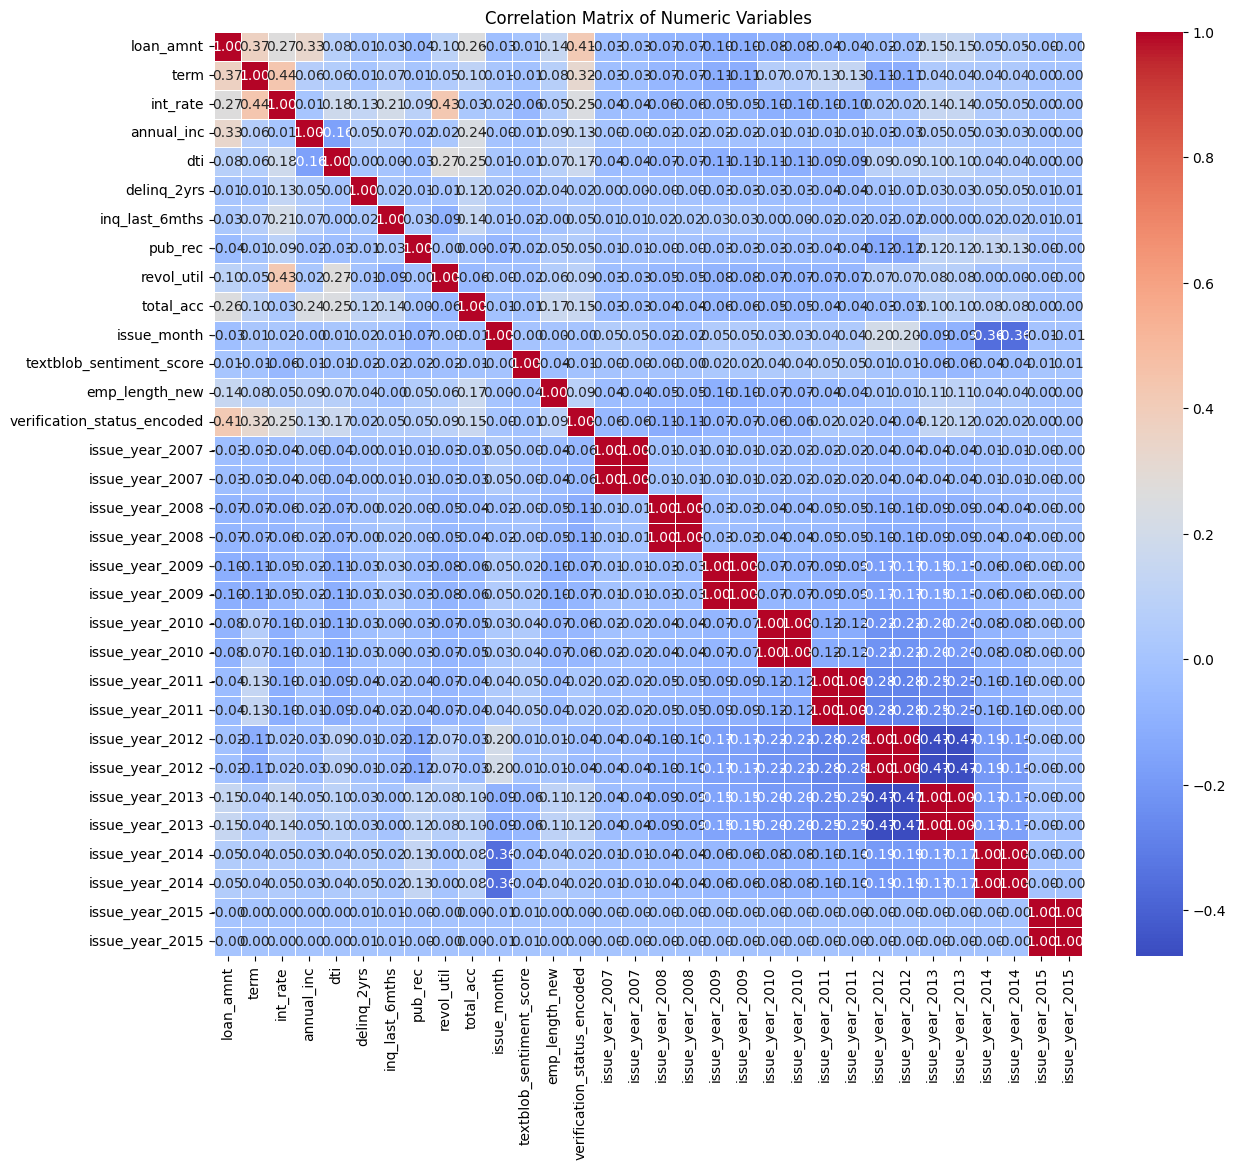

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
# Use the NUMERIC_COLS defined earlier to ensure we're looking at relevant features

# Remove 'issue_year' from NUMERIC_COLS and add the dummy year columns
updated_numeric_cols = [col for col in NUMERIC_COLS if col != 'issue_year'] + issue_year_cols

correlation_matrix = df[updated_numeric_cols].corr()

plt.figure(figsize=(14, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Create a list of numeric columns excluding 'textblob_sentiment_score'
numeric_cols_for_model = [col for col in NUMERIC_COLS if col != 'textblob_sentiment_score']

# Using TARGET_COL as dependent and the filtered numeric columns as independent variables
model_loan = f"{TARGET_COL} ~ " + " + ".join(numeric_cols_for_model)

cols_for_model = [TARGET_COL] + numeric_cols_for_model

# check missing values
print(df[cols_for_model].isna().sum())

df_model = df[cols_for_model].dropna()
print("df_model shape:", df_model.shape)

# IMPORTANT: df_model should NOT be (0, 14). If it is, something earlier is wrong.

logit_loan = smf.logit(formula=model_loan, data=df_model).fit()
print(logit_loan.summary())

loan_status                    0
loan_amnt                      0
term                           0
int_rate                       0
annual_inc                     0
dti                            0
delinq_2yrs                    0
inq_last_6mths                 0
pub_rec                        0
revol_util                     0
total_acc                      0
issue_year                     0
issue_month                    0
emp_length_new                 0
verification_status_encoded    0
dtype: int64
df_model shape: (84946, 15)
Optimization terminated successfully.
         Current function value: 0.418028
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                84946
Model:                          Logit   Df Residuals:                    84931
Method:                           MLE   Df Model:                           14
Date:                Wed, 11 Mar 2026   Pseudo

In [ ]:
# CELL 10: Odds ratios
# =======================

odds_table = np.exp(logit_loan.conf_int())
odds_table['odds'] = np.exp(logit_loan.params)
odds_table.columns = ['2.5%', '97.5%', 'odds']
print(odds_table)

                                     2.5%         97.5%      odds
Intercept                    4.431876e-14  2.947429e+14  3.614228
loan_amnt                    1.000008e+00  1.000014e+00  1.000011
term                         1.020300e+00  1.024686e+00  1.022491
int_rate                     1.112720e+00  1.125896e+00  1.119288
annual_inc                   9.999928e-01  9.999942e-01  0.999994
dti                          1.013760e+00  1.019701e+00  1.016726
delinq_2yrs                  9.842204e-01  1.043580e+00  1.013466
inq_last_6mths               1.071173e+00  1.110262e+00  1.090542
pub_rec                      9.804297e-01  1.093041e+00  1.035205
revol_util                   1.000472e+00  1.002269e+00  1.001370
total_acc                    9.914197e-01  9.953199e-01  0.993368
issue_year                   9.815772e-01  1.013349e+00  0.997337
issue_month                  9.865175e-01  9.974004e-01  0.991944
emp_length_new               1.002431e+00  1.013309e+00  1.007855
verificati

In [ ]:
import statsmodels.formula.api as smf

# Include 'textblob_sentiment_score' by using the original NUMERIC_COLS list
numeric_cols_for_model = NUMERIC_COLS

# Using TARGET_COL as dependent and the numeric columns as independent variables
model_loan = f"{TARGET_COL} ~ " + " + ".join(numeric_cols_for_model)

cols_for_model = [TARGET_COL] + numeric_cols_for_model

# check missing values
print(df[cols_for_model].isna().sum())

df_model = df[cols_for_model].dropna()
print("df_model shape:", df_model.shape)

# IMPORTANT: df_model should NOT be (0, 14). If it is, something earlier is wrong.

logit_loan = smf.logit(formula=model_loan, data=df_model).fit()
print(logit_loan.summary())

loan_status                    0
loan_amnt                      0
term                           0
int_rate                       0
annual_inc                     0
dti                            0
delinq_2yrs                    0
inq_last_6mths                 0
pub_rec                        0
revol_util                     0
total_acc                      0
issue_year                     0
issue_month                    0
textblob_sentiment_score       0
emp_length_new                 0
verification_status_encoded    0
dtype: int64
df_model shape: (84946, 16)
Optimization terminated successfully.
         Current function value: 0.418016
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                84946
Model:                          Logit   Df Residuals:                    84930
Method:                           MLE   Df Model:                           15
Date:        

In [ ]:
# CELL 10: Odds ratios
# =======================

odds_table = np.exp(logit_loan.conf_int())
odds_table['odds'] = np.exp(logit_loan.params)
odds_table.columns = ['2.5%', '97.5%', 'odds']
print(odds_table)

                                     2.5%         97.5%       odds
Intercept                    1.874680e-13  1.399357e+15  16.196751
loan_amnt                    1.000008e+00  1.000015e+00   1.000011
term                         1.020311e+00  1.024697e+00   1.022502
int_rate                     1.112502e+00  1.125689e+00   1.119076
annual_inc                   9.999928e-01  9.999942e-01   0.999994
dti                          1.013762e+00  1.019704e+00   1.016729
delinq_2yrs                  9.840562e-01  1.043409e+00   1.013298
inq_last_6mths               1.071163e+00  1.110252e+00   1.090532
pub_rec                      9.802369e-01  1.092833e+00   1.035005
revol_util                   1.000477e+00  1.002275e+00   1.001376
total_acc                    9.914264e-01  9.953264e-01   0.993374
issue_year                   9.808230e-01  1.012627e+00   0.996598
issue_month                  9.864580e-01  9.973411e-01   0.991885
textblob_sentiment_score     8.278632e-01  1.030653e+00   0.92

In [ ]:
!pip install imblearn

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# Combine numeric and categorical columns for feature selection
feature_cols = NUMERIC_COLS + CATEGORICAL_COLS

# Ensure all feature_cols exist in the DataFrame before dropping NaNs
# Also ensure 'loan_status' is present
all_model_cols = feature_cols + ['loan_status']

# Filter df to only include relevant columns and drop rows with any missing values
df_model = df[all_model_cols].dropna()

X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain the same proportion of target classes in train and test sets
)

print("Original Training data shape:", X_train.shape, y_train.shape)
print("Original Testing data shape:", X_test.shape, y_test.shape)
print("Original training class distribution:\n", y_train.value_counts())

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nResampled Training data shape:", X_train_resampled.shape, y_train_resampled.shape)
print("Resampled training class distribution:\n", y_train_resampled.value_counts())


model_LR = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42) # 'liblinear' is good for small datasets and L1/L2 regularization
model_LR.fit(X_train_resampled, y_train_resampled)

y_pred_LR = model_LR.predict(X_test)
y_prob_LR = model_LR.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

# Calculate evaluation metrics
acc_LR = accuracy_score(y_test, y_pred_LR)
prec_LR = precision_score(y_test, y_pred_LR)
rec_LR = recall_score(y_test, y_pred_LR)
f1_LR = f1_score(y_test, y_pred_LR)
auc_LR = roc_auc_score(y_test, y_prob_LR)

print(f"\nAccuracy of LR Model: {acc_LR:.4f}")
print(f"Precision of LR Model: {prec_LR:.4f}")
print(f"Recall of LR Model: {rec_LR:.4f}")
print(f"F1-Score of LR Model: {f1_LR:.4f}")
print(f"AUC of LR Model: {auc_LR:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Logistic Regression Model:\n", classification_report(y_test, y_pred_LR))

Original Training data shape: (67956, 16) (67956,)
Original Testing data shape: (16990, 16) (16990,)
Original training class distribution:
 loan_status
0    56470
1    11486
Name: count, dtype: int64

Resampled Training data shape: (112940, 16) (112940,)
Resampled training class distribution:
 loan_status
0    56470
1    56470
Name: count, dtype: int64

Accuracy of LR Model: 0.6648
Precision of LR Model: 0.2789
Recall of LR Model: 0.6198
F1-Score of LR Model: 0.3847
AUC of LR Model: 0.7006

Classification Report for Logistic Regression Model:
               precision    recall  f1-score   support

           0       0.90      0.67      0.77     14118
           1       0.28      0.62      0.38      2872

    accuracy                           0.66     16990
   macro avg       0.59      0.65      0.58     16990
weighted avg       0.79      0.66      0.70     16990



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Using the feature_cols (including sentiment) as defined for the first LR model
feature_cols_all = NUMERIC_COLS + CATEGORICAL_COLS
all_model_cols_all = feature_cols_all + ['loan_status']
df_model_all = df[all_model_cols_all].dropna()

X_all = df_model_all.drop('loan_status', axis=1)
y_all = df_model_all['loan_status']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all  # Maintain the same proportion of target classes in train and test sets
)

print("Original Training data shape:", X_train_full.shape, y_train_full.shape)
print("Original Testing data shape:", X_test_full.shape, y_test_full.shape)

# Scale the data BEFORE applying SMOTE to prevent data leakage and for LR performance
# Although LR is less sensitive than SVM, it's good practice.
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train_full)
X_test_scaled_lr = scaler_lr.transform(X_test_full)

# Apply SMOTE to balance the training data
smote_train_lr = SMOTE(random_state=42)
X_train_resampled_lr, y_train_resampled_lr = smote_train_lr.fit_resample(X_train_scaled_lr, y_train_full)

# Apply SMOTE to balance the testing data (as requested - with caution advised)
smote_test_lr = SMOTE(random_state=42)
X_test_resampled_lr, y_test_resampled_lr = smote_test_lr.fit_resample(X_test_scaled_lr, y_test_full)

print("\nResampled Training data shape (LR):", X_train_resampled_lr.shape, y_train_resampled_lr.shape)
print("Resampled Testing data shape (LR):", X_test_resampled_lr.shape, y_test_resampled_lr.shape)
print("Resampled training class distribution (LR):\n", y_train_resampled_lr.value_counts())
print("Resampled testing class distribution (LR):\n", y_test_resampled_lr.value_counts())


# Initialize and train the Logistic Regression model
model_LR_resampled_test = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)
model_LR_resampled_test.fit(X_train_resampled_lr, y_train_resampled_lr)

# Make predictions on the resampled test set
y_pred_LR_resampled_test = model_LR_resampled_test.predict(X_test_resampled_lr)
y_prob_LR_resampled_test = model_LR_resampled_test.predict_proba(X_test_resampled_lr)[:, 1]

# Calculate evaluation metrics
acc_LR_resampled_test = accuracy_score(y_test_resampled_lr, y_pred_LR_resampled_test)
prec_LR_resampled_test = precision_score(y_test_resampled_lr, y_pred_LR_resampled_test)
rec_LR_resampled_test = recall_score(y_test_resampled_lr, y_pred_LR_resampled_test)
f1_LR_resampled_test = f1_score(y_test_resampled_lr, y_pred_LR_resampled_test)
auc_LR_resampled_test = roc_auc_score(y_test_resampled_lr, y_prob_LR_resampled_test)

print(f"\nAccuracy of Logistic Regression Model (Resampled Test Set): {acc_LR_resampled_test:.4f}")
print(f"Precision of Logistic Regression Model (Resampled Test Set): {prec_LR_resampled_test:.4f}")
print(f"Recall of Logistic Regression Model (Resampled Test Set): {rec_LR_resampled_test:.4f}")
print(f"F1-Score of Logistic Regression Model (Resampled Test Set): {f1_LR_resampled_test:.4f}")
print(f"AUC of Logistic Regression Model (Resampled Test Set): {auc_LR_resampled_test:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Logistic Regression Model (Resampled Test Set):\n", classification_report(y_test_resampled_lr, y_pred_LR_resampled_test))

Original Training data shape: (67956, 16) (67956,)
Original Testing data shape: (16990, 16) (16990,)

Resampled Training data shape (LR): (112940, 16) (112940,)
Resampled Testing data shape (LR): (28236, 16) (28236,)
Resampled training class distribution (LR):
 loan_status
0    56470
1    56470
Name: count, dtype: int64
Resampled testing class distribution (LR):
 loan_status
0    14118
1    14118
Name: count, dtype: int64

Accuracy of Logistic Regression Model (Resampled Test Set): 0.6560
Precision of Logistic Regression Model (Resampled Test Set): 0.6602
Recall of Logistic Regression Model (Resampled Test Set): 0.6430
F1-Score of Logistic Regression Model (Resampled Test Set): 0.6515
AUC of Logistic Regression Model (Resampled Test Set): 0.7165

Classification Report for Logistic Regression Model (Resampled Test Set):
               precision    recall  f1-score   support

           0       0.65      0.67      0.66     14118
           1       0.66      0.64      0.65     14118

    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# Combine numeric and categorical columns for feature selection, EXCLUDING textblob_sentiment_score
feature_cols_no_sentiment = [col for col in NUMERIC_COLS if col != 'textblob_sentiment_score'] + CATEGORICAL_COLS

# Ensure all feature_cols_no_sentiment exist in the DataFrame before dropping NaNs
# Also ensure 'loan_status' is present
all_model_cols_no_sentiment = feature_cols_no_sentiment + ['loan_status']

# Filter df to only include relevant columns and drop rows with any missing values
df_model_no_sentiment = df[all_model_cols_no_sentiment].dropna()

X_no_sentiment = df_model_no_sentiment.drop('loan_status', axis=1)
y_no_sentiment = df_model_no_sentiment['loan_status']

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sentiment, y_no_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_no_sentiment  # Maintain the same proportion of target classes in train and test sets
)

print("Original Training data shape (no sentiment):", X_train_ns.shape, y_train_ns.shape)
print("Original Testing data shape (no sentiment):", X_test_ns.shape, y_test_ns.shape)
print("Original training class distribution (no sentiment):\n", y_train_ns.value_counts())

# Apply SMOTE to balance the training data
smote_ns = SMOTE(random_state=42)
X_train_resampled_ns, y_train_resampled_ns = smote_ns.fit_resample(X_train_ns, y_train_ns)

print("\nResampled Training data shape (no sentiment):", X_train_resampled_ns.shape, y_train_resampled_ns.shape)
print("Resampled training class distribution (no sentiment):\n", y_train_resampled_ns.value_counts())


model_LR_no_sentiment = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)
model_LR_no_sentiment.fit(X_train_resampled_ns, y_train_resampled_ns)

y_pred_LR_no_sentiment = model_LR_no_sentiment.predict(X_test_ns)
y_prob_LR_no_sentiment = model_LR_no_sentiment.predict_proba(X_test_ns)[:, 1]

# Calculate evaluation metrics
acc_LR_no_sentiment = accuracy_score(y_test_ns, y_pred_LR_no_sentiment)
prec_LR_no_sentiment = precision_score(y_test_ns, y_pred_LR_no_sentiment)
rec_LR_no_sentiment = recall_score(y_test_ns, y_pred_LR_no_sentiment)
f1_LR_no_sentiment = f1_score(y_test_ns, y_pred_LR_no_sentiment)
auc_LR_no_sentiment = roc_auc_score(y_test_ns, y_prob_LR_no_sentiment)

print(f"\nAccuracy of LR Model (no sentiment): {acc_LR_no_sentiment:.4f}")
print(f"Precision of LR Model (no sentiment): {prec_LR_no_sentiment:.4f}")
print(f"Recall of LR Model (no sentiment): {rec_LR_no_sentiment:.4f}")
print(f"F1-Score of LR Model (no sentiment): {f1_LR_no_sentiment:.4f}")
print(f"AUC of LR Model (no sentiment): {auc_LR_no_sentiment:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Logistic Regression Model (no sentiment):\n", classification_report(y_test_ns, y_pred_LR_no_sentiment))

Original Training data shape (no sentiment): (67956, 15) (67956,)
Original Testing data shape (no sentiment): (16990, 15) (16990,)
Original training class distribution (no sentiment):
 loan_status
0    56470
1    11486
Name: count, dtype: int64

Resampled Training data shape (no sentiment): (112940, 15) (112940,)
Resampled training class distribution (no sentiment):
 loan_status
0    56470
1    56470
Name: count, dtype: int64

Accuracy of LR Model (no sentiment): 0.6642
Precision of LR Model (no sentiment): 0.2786
Recall of LR Model (no sentiment): 0.6205
F1-Score of LR Model (no sentiment): 0.3845
AUC of LR Model (no sentiment): 0.7006

Classification Report for Logistic Regression Model (no sentiment):
               precision    recall  f1-score   support

           0       0.90      0.67      0.77     14118
           1       0.28      0.62      0.38      2872

    accuracy                           0.66     16990
   macro avg       0.59      0.65      0.58     16990
weighted avg 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Initialize and train the Random Forest model
# Using the resampled data from the previous Logistic Regression model (with sentiment)
model_RF = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model_RF.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_RF = model_RF.predict(X_test)
y_prob_RF = model_RF.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

# Calculate evaluation metrics
acc_RF = accuracy_score(y_test, y_pred_RF)
prec_RF = precision_score(y_test, y_pred_RF)
rec_RF = recall_score(y_test, y_pred_RF)
f1_RF = f1_score(y_test, y_pred_RF)
auc_RF = roc_auc_score(y_test, y_prob_RF)

print(f"\nAccuracy of Random Forest Model: {acc_RF:.4f}")
print(f"Precision of Random Forest Model: {prec_RF:.4f}")
print(f"Recall of Random Forest Model: {rec_RF:.4f}")
print(f"F1-Score of Random Forest Model: {f1_RF:.4f}")
print(f"AUC of Random Forest Model: {auc_RF:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Random Forest Model:\n", classification_report(y_test, y_pred_RF))


Accuracy of Random Forest Model: 0.8207
Precision of Random Forest Model: 0.4014
Recall of Random Forest Model: 0.1240
F1-Score of Random Forest Model: 0.1894
AUC of Random Forest Model: 0.6803

Classification Report for Random Forest Model:
               precision    recall  f1-score   support

           0       0.84      0.96      0.90     14118
           1       0.40      0.12      0.19      2872

    accuracy                           0.82     16990
   macro avg       0.62      0.54      0.54     16990
weighted avg       0.77      0.82      0.78     16990



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# Using the feature_cols (including sentiment) as defined for the first LR model
feature_cols_all = NUMERIC_COLS + CATEGORICAL_COLS
all_model_cols_all = feature_cols_all + ['loan_status']
df_model_all = df[all_model_cols_all].dropna()

X_all = df_model_all.drop('loan_status', axis=1)
y_all = df_model_all['loan_status']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all  # Maintain the same proportion of target classes in train and test sets
)

print("Original Training data shape:", X_train_full.shape, y_train_full.shape)
print("Original Testing data shape:", X_test_full.shape, y_test_full.shape)

# Apply SMOTE to balance the training data
smote_train = SMOTE(random_state=42)
X_train_resampled_rf, y_train_resampled_rf = smote_train.fit_resample(X_train_full, y_train_full)

# Apply SMOTE to balance the testing data (as requested - with caution advised)
smote_test = SMOTE(random_state=42)
X_test_resampled_rf, y_test_resampled_rf = smote_test.fit_resample(X_test_full, y_test_full)

print("\nResampled Training data shape:", X_train_resampled_rf.shape, y_train_resampled_rf.shape)
print("Resampled Testing data shape:", X_test_resampled_rf.shape, y_test_resampled_rf.shape)
print("Resampled training class distribution:\n", y_train_resampled_rf.value_counts())
print("Resampled testing class distribution:\n", y_test_resampled_rf.value_counts())


# Initialize and train the Random Forest model
model_RF_resampled_test = RandomForestClassifier(random_state=42, n_jobs=-1)
model_RF_resampled_test.fit(X_train_resampled_rf, y_train_resampled_rf)

# Make predictions on the resampled test set
y_pred_RF_resampled_test = model_RF_resampled_test.predict(X_test_resampled_rf)
y_prob_RF_resampled_test = model_RF_resampled_test.predict_proba(X_test_resampled_rf)[:, 1]

# Calculate evaluation metrics
acc_RF_resampled_test = accuracy_score(y_test_resampled_rf, y_pred_RF_resampled_test)
prec_RF_resampled_test = precision_score(y_test_resampled_rf, y_pred_RF_resampled_test)
rec_RF_resampled_test = recall_score(y_test_resampled_rf, y_pred_RF_resampled_test)
f1_RF_resampled_test = f1_score(y_test_resampled_rf, y_pred_RF_resampled_test)
auc_RF_resampled_test = roc_auc_score(y_test_resampled_rf, y_prob_RF_resampled_test)

print(f"\nAccuracy of Random Forest Model (Resampled Test Set): {acc_RF_resampled_test:.4f}")
print(f"Precision of Random Forest Model (Resampled Test Set): {prec_RF_resampled_test:.4f}")
print(f"Recall of Random Forest Model (Resampled Test Set): {rec_RF_resampled_test:.4f}")
print(f"F1-Score of Random Forest Model (Resampled Test Set): {f1_RF_resampled_test:.4f}")
print(f"AUC of Random Forest Model (Resampled Test Set): {auc_RF_resampled_test:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Random Forest Model (Resampled Test Set):\n", classification_report(y_test_resampled_rf, y_pred_RF_resampled_test))

Original Training data shape: (67956, 16) (67956,)
Original Testing data shape: (16990, 16) (16990,)

Resampled Training data shape: (112940, 16) (112940,)
Resampled Testing data shape: (28236, 16) (28236,)
Resampled training class distribution:
 loan_status
0    56470
1    56470
Name: count, dtype: int64
Resampled testing class distribution:
 loan_status
0    14118
1    14118
Name: count, dtype: int64

Accuracy of Random Forest Model (Resampled Test Set): 0.8658
Precision of Random Forest Model (Resampled Test Set): 0.9534
Recall of Random Forest Model (Resampled Test Set): 0.7692
F1-Score of Random Forest Model (Resampled Test Set): 0.8514
AUC of Random Forest Model (Resampled Test Set): 0.9234

Classification Report for Random Forest Model (Resampled Test Set):
               precision    recall  f1-score   support

           0       0.81      0.96      0.88     14118
           1       0.95      0.77      0.85     14118

    accuracy                           0.87     28236
   mac

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Linear SVM model
# LinearSVC is generally faster for large datasets than SVC with a linear kernel
model_SVM = LinearSVC(random_state=42, max_iter=2000, dual=False) # dual=False for n_samples > n_features

# Warning: SVMs are sensitive to feature scaling. For better performance, consider scaling features.
# Example: from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# model_SVM.fit(X_train_scaled, y_train)

model_SVM.fit(X_train, y_train)

# Make predictions on the test set
y_pred_SVM = model_SVM.predict(X_test)

# Calculate and print the accuracy
acc_SVM = accuracy_score(y_test, y_pred_SVM)
print(f"Accuracy of Linear SVM Model: {acc_SVM:.4f}")

# Optional: Print classification report for more detailed metrics
# print("\nClassification Report for Linear SVM Model:")
# print(classification_report(y_test, y_pred_SVM))

Accuracy of Linear SVM Model: 0.8881


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Initialize and train the Linear SVM model
# LinearSVC is generally faster for large datasets than SVC with a linear kernel
# For AUC, we need decision_function scores, as LinearSVC doesn't have predict_proba by default.
# Also, LinearSVC is sensitive to feature scaling, so scaling is often recommended for better performance.

# Using the resampled data from the previous Logistic Regression model (with sentiment)
# X_train_resampled, y_train_resampled, X_test, y_test are already available.

model_SVM = LinearSVC(random_state=42, max_iter=2000, dual=False) # dual=False for n_samples > n_features

# Before training SVM, it's highly recommended to scale the features.
# This wasn't explicitly requested but is crucial for SVM performance.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

model_SVM.fit(X_train_scaled, y_train_resampled)

# Make predictions on the scaled test set
y_pred_SVM = model_SVM.predict(X_test_scaled)

# For AUC, use decision_function for LinearSVC
y_score_SVM = model_SVM.decision_function(X_test_scaled)

# Calculate evaluation metrics
acc_SVM = accuracy_score(y_test, y_pred_SVM)
prec_SVM = precision_score(y_test, y_pred_SVM)
rec_SVM = recall_score(y_test, y_pred_SVM)
f1_SVM = f1_score(y_test, y_pred_SVM)
auc_SVM = roc_auc_score(y_test, y_score_SVM)

print(f"\nAccuracy of Linear SVM Model: {acc_SVM:.4f}")
print(f"Precision of Linear SVM Model: {prec_SVM:.4f}")
print(f"Recall of Linear SVM Model: {rec_SVM:.4f}")
print(f"F1-Score of Linear SVM Model: {f1_SVM:.4f}")
print(f"AUC of Linear SVM Model: {auc_SVM:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Linear SVM Model:\n", classification_report(y_test, y_pred_SVM))


Accuracy of Linear SVM Model: 0.6599
Precision of Linear SVM Model: 0.2628
Recall of Linear SVM Model: 0.5606
F1-Score of Linear SVM Model: 0.3578
AUC of Linear SVM Model: 0.6729

Classification Report for Linear SVM Model:
               precision    recall  f1-score   support

           0       0.88      0.68      0.77     14118
           1       0.26      0.56      0.36      2872

    accuracy                           0.66     16990
   macro avg       0.57      0.62      0.56     16990
weighted avg       0.78      0.66      0.70     16990



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Using the feature_cols (including sentiment) as defined for the first LR model
feature_cols_all = NUMERIC_COLS + CATEGORICAL_COLS
all_model_cols_all = feature_cols_all + ['loan_status']
df_model_all = df[all_model_cols_all].dropna()

X_all = df_model_all.drop('loan_status', axis=1)
y_all = df_model_all['loan_status']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all  # Maintain the same proportion of target classes in train and test sets
)

print("Original Training data shape:", X_train_full.shape, y_train_full.shape)
print("Original Testing data shape:", X_test_full.shape, y_test_full.shape)

# Scale the data BEFORE applying SMOTE to prevent data leakage and for SVM performance
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled_full = scaler.transform(X_test_full)

# Apply SMOTE to balance the training data
smote_train = SMOTE(random_state=42)
X_train_resampled_svm, y_train_resampled_svm = smote_train.fit_resample(X_train_scaled_full, y_train_full)

# Apply SMOTE to balance the testing data (as requested - with caution advised)
smote_test = SMOTE(random_state=42)
X_test_resampled_svm, y_test_resampled_svm = smote_test.fit_resample(X_test_scaled_full, y_test_full)

print("\nResampled Training data shape:", X_train_resampled_svm.shape, y_train_resampled_svm.shape)
print("Resampled Testing data shape:", X_test_resampled_svm.shape, y_test_resampled_svm.shape)
print("Resampled training class distribution:\n", y_train_resampled_svm.value_counts())
print("Resampled testing class distribution:\n", y_test_resampled_svm.value_counts())


# Initialize and train the Linear SVM model
model_SVM_resampled_test = LinearSVC(random_state=42, max_iter=2000, dual=False) # dual=False for n_samples > n_features
model_SVM_resampled_test.fit(X_train_resampled_svm, y_train_resampled_svm)

# Make predictions on the resampled test set
y_pred_SVM_resampled_test = model_SVM_resampled_test.predict(X_test_resampled_svm)

# For AUC, use decision_function for LinearSVC
y_score_SVM_resampled_test = model_SVM_resampled_test.decision_function(X_test_resampled_svm)

# Calculate evaluation metrics
acc_SVM_resampled_test = accuracy_score(y_test_resampled_svm, y_pred_SVM_resampled_test)
prec_SVM_resampled_test = precision_score(y_test_resampled_svm, y_pred_SVM_resampled_test)
rec_SVM_resampled_test = recall_score(y_test_resampled_svm, y_pred_SVM_resampled_test)
f1_SVM_resampled_test = f1_score(y_test_resampled_svm, y_pred_SVM_resampled_test)
auc_SVM_resampled_test = roc_auc_score(y_test_resampled_svm, y_score_SVM_resampled_test)

print(f"\nAccuracy of Linear SVM Model (Resampled Test Set): {acc_SVM_resampled_test:.4f}")
print(f"Precision of Linear SVM Model (Resampled Test Set): {prec_SVM_resampled_test:.4f}")
print(f"Recall of Linear SVM Model (Resampled Test Set): {rec_SVM_resampled_test:.4f}")
print(f"F1-Score of Linear SVM Model (Resampled Test Set): {f1_SVM_resampled_test:.4f}")
print(f"AUC of Linear SVM Model (Resampled Test Set): {auc_SVM_resampled_test:.4f}")

# Optional: Print full classification report
print("\nClassification Report for Linear SVM Model (Resampled Test Set):\n", classification_report(y_test_resampled_svm, y_pred_SVM_resampled_test))

Original Training data shape: (67956, 16) (67956,)
Original Testing data shape: (16990, 16) (16990,)

Resampled Training data shape: (112940, 16) (112940,)
Resampled Testing data shape: (28236, 16) (28236,)
Resampled training class distribution:
 loan_status
0    56470
1    56470
Name: count, dtype: int64
Resampled testing class distribution:
 loan_status
0    14118
1    14118
Name: count, dtype: int64

Accuracy of Linear SVM Model (Resampled Test Set): 0.6537
Precision of Linear SVM Model (Resampled Test Set): 0.6598
Recall of Linear SVM Model (Resampled Test Set): 0.6347
F1-Score of Linear SVM Model (Resampled Test Set): 0.6470
AUC of Linear SVM Model (Resampled Test Set): 0.7159

Classification Report for Linear SVM Model (Resampled Test Set):
               precision    recall  f1-score   support

           0       0.65      0.67      0.66     14118
           1       0.66      0.63      0.65     14118

    accuracy                           0.65     28236
   macro avg       0.65 

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the XGBoost model
# n_jobs=-1 uses all available cores, random_state for reproducibility
model_XGB = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
model_XGB.fit(X_train, y_train)

# Make predictions on the test set
y_pred_XGB = model_XGB.predict(X_test)

# Calculate and print the accuracy
acc_XGB = accuracy_score(y_test, y_pred_XGB)
print(f"Accuracy of XGBoost Model: {acc_XGB:.4f}")

# Optional: Print classification report for more detailed metrics
# print("\nClassification Report for XGBoost Model:")
# print(classification_report(y_test, y_pred_XGB))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:34:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of XGBoost Model: 0.8879


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Initialize and train the XGBoost model
# n_jobs=-1 uses all available cores, random_state for reproducibility
# Use X_train_resampled and y_train_resampled (from the LR model with sentiment and SMOTE)
# and X_test, y_test (original imbalanced test set)
model_XGB = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
model_XGB.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_XGB = model_XGB.predict(X_test)
y_prob_XGB = model_XGB.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

# Calculate evaluation metrics
acc_XGB = accuracy_score(y_test, y_pred_XGB)
prec_XGB = precision_score(y_test, y_pred_XGB)
rec_XGB = recall_score(y_test, y_pred_XGB)
f1_XGB = f1_score(y_test, y_pred_XGB)
auc_XGB = roc_auc_score(y_test, y_prob_XGB)

print(f"\nAccuracy of XGBoost Model: {acc_XGB:.4f}")
print(f"Precision of XGBoost Model: {prec_XGB:.4f}")
print(f"Recall of XGBoost Model: {rec_XGB:.4f}")
print(f"F1-Score of XGBoost Model: {f1_XGB:.4f}")
print(f"AUC of XGBoost Model: {auc_XGB:.4f}")

# Optional: Print full classification report
print("\nClassification Report for XGBoost Model:\n", classification_report(y_test, y_pred_XGB))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:59:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy of XGBoost Model: 0.8265
Precision of XGBoost Model: 0.4396
Recall of XGBoost Model: 0.0951
F1-Score of XGBoost Model: 0.1563
AUC of XGBoost Model: 0.6881

Classification Report for XGBoost Model:
               precision    recall  f1-score   support

           0       0.84      0.98      0.90     14118
           1       0.44      0.10      0.16      2872

    accuracy                           0.83     16990
   macro avg       0.64      0.54      0.53     16990
weighted avg       0.77      0.83      0.78     16990



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# Using the feature_cols (including sentiment) as defined for the first LR model
feature_cols_all = NUMERIC_COLS + CATEGORICAL_COLS
all_model_cols_all = feature_cols_all + ['loan_status']
df_model_all = df[all_model_cols_all].dropna()

X_all = df_model_all.drop('loan_status', axis=1)
y_all = df_model_all['loan_status']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all  # Maintain the same proportion of target classes in train and test sets
)

print("Original Training data shape:", X_train_full.shape, y_train_full.shape)
print("Original Testing data shape:", X_test_full.shape, y_test_full.shape)

# Apply SMOTE to balance the training data
smote_train = SMOTE(random_state=42)
X_train_resampled_xgb, y_train_resampled_xgb = smote_train.fit_resample(X_train_full, y_train_full)

# Apply SMOTE to balance the testing data (as requested - with caution advised)
smote_test = SMOTE(random_state=42)
X_test_resampled_xgb, y_test_resampled_xgb = smote_test.fit_resample(X_test_full, y_test_full)

print("\nResampled Training data shape:", X_train_resampled_xgb.shape, y_train_resampled_xgb.shape)
print("Resampled Testing data shape:", X_test_resampled_xgb.shape, y_test_resampled_xgb.shape)
print("Resampled training class distribution:\n", y_train_resampled_xgb.value_counts())
print("Resampled testing class distribution:\n", y_test_resampled_xgb.value_counts())


# Initialize and train the XGBoost model
model_XGB_resampled_test = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
model_XGB_resampled_test.fit(X_train_resampled_xgb, y_train_resampled_xgb)

# Make predictions on the resampled test set
y_pred_XGB_resampled_test = model_XGB_resampled_test.predict(X_test_resampled_xgb)
y_prob_XGB_resampled_test = model_XGB_resampled_test.predict_proba(X_test_resampled_xgb)[:, 1]

# Calculate evaluation metrics
acc_XGB_resampled_test = accuracy_score(y_test_resampled_xgb, y_pred_XGB_resampled_test)
prec_XGB_resampled_test = precision_score(y_test_resampled_xgb, y_pred_XGB_resampled_test)
rec_XGB_resampled_test = recall_score(y_test_resampled_xgb, y_pred_XGB_resampled_test)
f1_XGB_resampled_test = f1_score(y_test_resampled_xgb, y_pred_XGB_resampled_test)
auc_XGB_resampled_test = roc_auc_score(y_test_resampled_xgb, y_prob_XGB_resampled_test)

print(f"\nAccuracy of XGBoost Model (Resampled Test Set): {acc_XGB_resampled_test:.4f}")
print(f"Precision of XGBoost Model (Resampled Test Set): {prec_XGB_resampled_test:.4f}")
print(f"Recall of XGBoost Model (Resampled Test Set): {rec_XGB_resampled_test:.4f}")
print(f"F1-Score of XGBoost Model (Resampled Test Set): {f1_XGB_resampled_test:.4f}")
print(f"AUC of XGBoost Model (Resampled Test Set): {auc_XGB_resampled_test:.4f}")

# Optional: Print full classification report
print("\nClassification Report for XGBoost Model (Resampled Test Set):\n", classification_report(y_test_resampled_xgb, y_pred_XGB_resampled_test))

Original Training data shape: (67956, 16) (67956,)
Original Testing data shape: (16990, 16) (16990,)

Resampled Training data shape: (112940, 16) (112940,)
Resampled Testing data shape: (28236, 16) (28236,)
Resampled training class distribution:
 loan_status
0    56470
1    56470
Name: count, dtype: int64
Resampled testing class distribution:
 loan_status
0    14118
1    14118
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:35:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy of XGBoost Model (Resampled Test Set): 0.8906
Precision of XGBoost Model (Resampled Test Set): 0.9703
Recall of XGBoost Model (Resampled Test Set): 0.8059
F1-Score of XGBoost Model (Resampled Test Set): 0.8805
AUC of XGBoost Model (Resampled Test Set): 0.9342

Classification Report for XGBoost Model (Resampled Test Set):
               precision    recall  f1-score   support

           0       0.83      0.98      0.90     14118
           1       0.97      0.81      0.88     14118

    accuracy                           0.89     28236
   macro avg       0.90      0.89      0.89     28236
weighted avg       0.90      0.89      0.89     28236

